In [67]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [68]:
def generate_cigar_data(n_samples=1000):
    np.random.seed(42)
    X = np.random.randn(n_samples, 2)
    X[:, 0] *= 100.0
    X[:, 1] *= 0.01
    theta = np.radians(30)
    R = np.array([[np.cos(theta), -np.sin(theta)], 
                  [np.sin(theta), np.cos(theta)]])
    X = X @ R
    true_w = np.array([1.5, -2.0])
    y = X @ true_w + np.random.normal(0, 1, n_samples)
    return X, y

X, y = generate_cigar_data()

In [69]:
X

array([[ 43.01601617, -24.83690505],
       [ 56.09908792, -32.37123708],
       [-20.27944777,  11.70564105],
       ...,
       [ 30.44165834, -17.5631426 ],
       [ -2.3012178 ,   1.3184257 ],
       [-14.12573784,   8.14689715]], shape=(1000, 2))

In [70]:
y

array([ 113.52265609,  148.74658737,  -54.62287368,  362.75154585,
       -109.83289317, -106.32362605,   55.64804311, -397.37674929,
       -232.19757443, -207.80675537,  335.3528943 ,   14.77625855,
       -125.92589444, -265.56140203, -137.25678416, -138.54665945,
         -3.35719098,  187.1143366 ,   48.67319937, -306.59622546,
        169.83453042,  -26.30764688, -338.55011176, -107.22181062,
         75.99695595,   74.69577076, -153.83244312,  238.26051962,
       -192.72661045,   75.65750865, -109.35503734, -255.31242513,
        187.26582156,  -16.05978639,   84.20804551,   85.83078257,
         -7.85949254, -602.80641727,   19.98981478,   19.34659522,
        -51.20162425,  339.36927974, -186.39492101,  210.60356143,
       -122.62135001,   23.4300166 , -161.40125663,  -90.14208642,
         67.74872167,    1.33309762, -324.56989775,  -79.65062473,
        -37.74228418,  433.33588566,   57.86667641, -441.95181148,
         13.34674361,  -43.35309098,   -7.70632979,  262.92552

In [71]:
def mse_loss(X, y, w):
    pred = X @ w
    return np.mean((y - pred) ** 2)

def mse_grad(X, y, w):
    n = len(y)
    pred = X @ w
    return (2/n) * X.T @ (pred - y)

In [72]:
def logcosh_loss(X, y, w):
    r = X @ w - y
    return np.mean(np.abs(r) + np.log1p(np.exp(-2 * np.abs(r))) - np.log(2.0))

def logcosh_grad(X, y, w):
    n = len(y)
    pred = X @ w
    return (1/n) * X.T @ np.tanh(pred - y)

In [73]:
def sigmoid(z):
    return np.where(z >= 0, 
                    1 / (1 + np.exp(-z)), 
                    np.exp(z) / (1 + np.exp(z)))

def binary_focal_loss(X, y, w, gamma=2.0):
    wtx = X @ w
    pred = sigmoid(wtx)
    eps = 1e-8
    pred = np.clip(pred, eps, 1 - eps)
    loss = -(y * ((1 - pred)**gamma) * np.log(pred) + (1 - y) * (pred**gamma) * np.log(1 - pred))
    return np.mean(loss)

def binary_focal_grad(X, y, w, gamma=2.0):
    z = X @ w
    p = sigmoid(z)
    eps = 1e-7
    p = np.clip(p, eps, 1 - eps)
    y_n = (y - y.min()) / (y.max() - y.min() + eps)

    term1 = y_n * (gamma * (1 - p)**(gamma - 1) * np.log(p) * p * (1-p) - (1 - p)**gamma / p * p * (1-p))
    term0 = (1 - y_n) * (-gamma * p**(gamma - 1) * np.log(1 - p) * p * (1-p) + p**gamma / (1 - p) * p * (1-p))
    dLdz = -(term1 + term0)
    grad = (X.T @ dLdz) / X.shape[0]
    return grad

In [74]:
def batch_gd(X, y, w_init, loss_fn, grad_fn, lr=0.001, epochs=200):
    w = w_init.copy()
    history = {'w': [w.copy()], 'loss': [], 'time': []}
    start = time.time()
    for i in range(epochs):
        loss = loss_fn(X, y, w)
        history['loss'].append(loss)
        history['time'].append(time.time() - start)
        grad = grad_fn(X, y, w)
        w = w - lr * grad
        history['w'].append(w.copy())
        # print(np.array(history['w']).shape)
    return w, history

In [75]:
def stochastic_gd(X, y, w_init, loss_fn, grad_fn, lr=0.001, epochs=200):
    w = w_init.copy()
    history = {'w': [w.copy()], 'loss': [], 'time': []}
    n = len(y)
    start = time.time()
    for i in range(epochs):
        loss = loss_fn(X, y, w)
        history['loss'].append(loss)
        history['time'].append(time.time() - start)
        idx = np.random.randint(0, n)
        grad = grad_fn(X[idx:idx+1], y[idx:idx+1], w)
        w = w - lr * grad
        history['w'].append(w.copy())
        # print(np.array(history['w']).shape)
    return w, history

In [76]:
def mini_batch_gd(X, y, w_init, loss_fn, grad_fn, lr=0.001, epochs=200, batch_size=32):
    w = w_init.copy()
    history = {'w': [w.copy()], 'loss': [], 'time': []}
    n = len(y)
    start = time.time()
    for i in range(epochs):
        loss = loss_fn(X, y, w)
        history['loss'].append(loss)
        history['time'].append(time.time() - start)
        idx = np.random.choice(n, size=min(batch_size, n), replace=False)
        grad = grad_fn(X[idx], y[idx], w)
        w = w - lr * grad
        history['w'].append(w.copy())
        # print(np.array(history['w']).shape)
    return w, history

In [77]:
w_init = np.array([0.0, 0.0])
lr = 0.0001

w_bgd, h_bgd = batch_gd(X, y, w_init, mse_loss, mse_grad, lr, epochs=200)
w_sgd, h_sgd = stochastic_gd(X, y, w_init, mse_loss, mse_grad, lr, epochs=200)
w_mbgd, h_mbgd = mini_batch_gd(X, y, w_init, mse_loss, mse_grad, lr, epochs=200)

print("Batch GD:", w_bgd, "Loss:", h_bgd['loss'][-1])
print("Stochastic GD:", w_sgd, "Loss:", h_sgd['loss'][-1])
print("Mini-Batch GD:", w_mbgd, "Loss:", h_mbgd['loss'][-1])

Batch GD: [ 1.9912695  -1.14965512] Loss: 0.9652720232327865
Stochastic GD: [ 91.23003837 153.20683663] Loss: 231.76041943355514
Mini-Batch GD: [ 1.98474055 -1.14614165] Loss: 0.9900259864705923


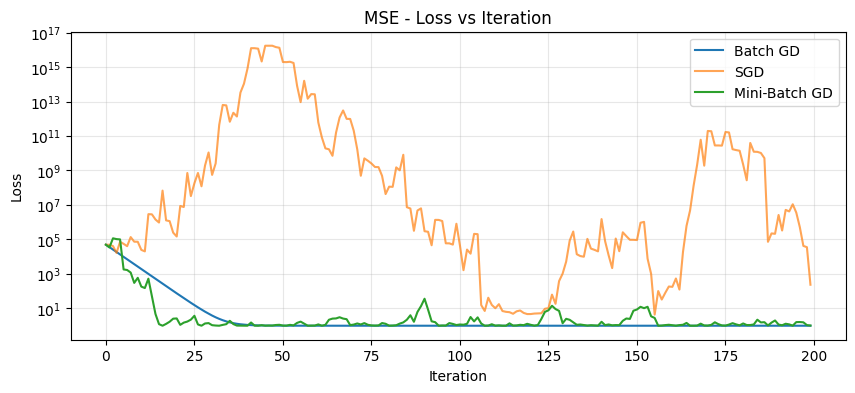

In [78]:
plt.figure(figsize=(10, 4))
plt.plot(h_bgd['loss'], label='Batch GD')
plt.plot(h_sgd['loss'], label='SGD', alpha=0.7)
plt.plot(h_mbgd['loss'], label='Mini-Batch GD')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MSE - Loss vs Iteration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

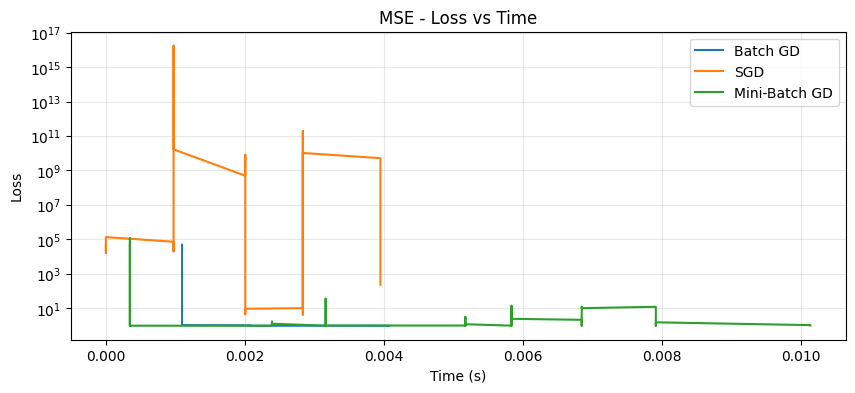

In [79]:
plt.figure(figsize=(10, 4))
plt.plot(h_bgd['time'], h_bgd['loss'], label='Batch GD')
plt.plot(h_sgd['time'], h_sgd['loss'], label='SGD')
plt.plot(h_mbgd['time'], h_mbgd['loss'], label='Mini-Batch GD')
plt.yscale('log')
plt.xlabel('Time (s)')
plt.ylabel('Loss')
plt.title('MSE - Loss vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

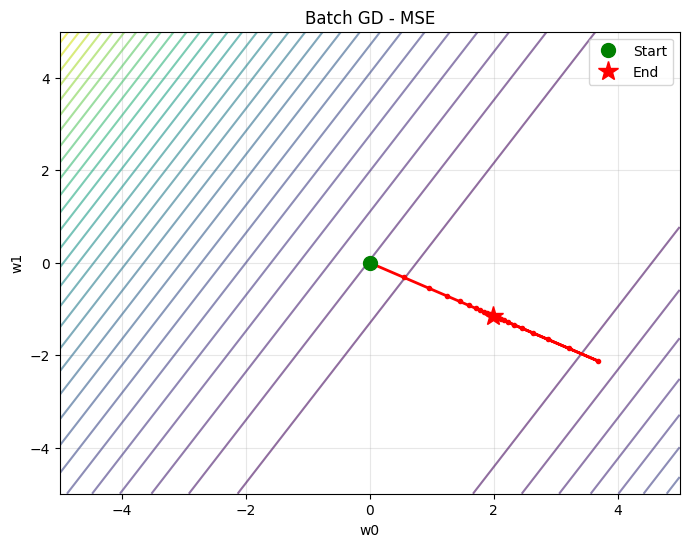

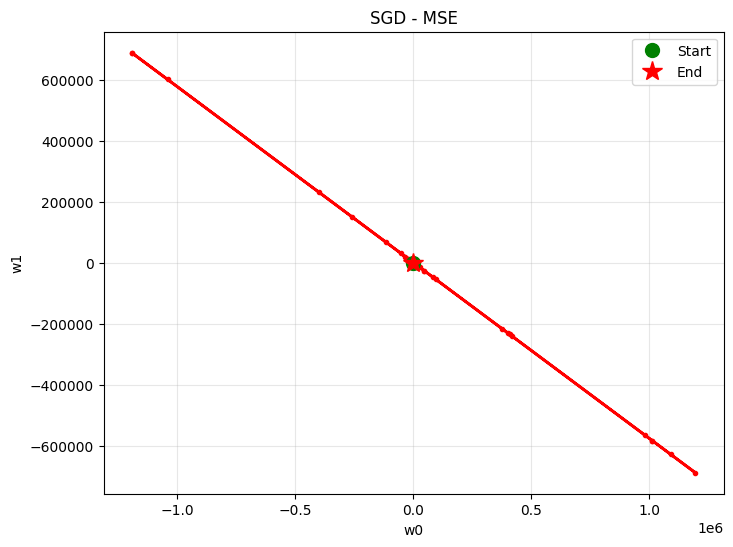

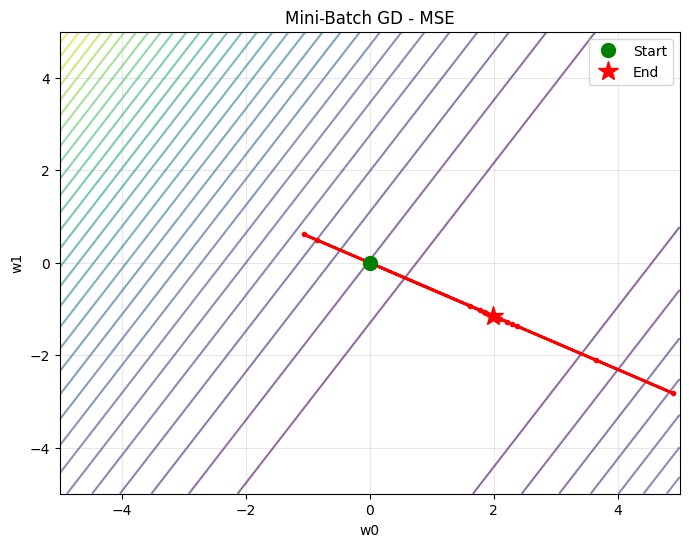

In [80]:
w0_range = np.linspace(-5, 5, 100)
w1_range = np.linspace(-5, 5, 100)
W0, W1 = np.meshgrid(w0_range, w1_range)
Z = np.zeros_like(W0)

for i in range(len(w0_range)):
    for j in range(len(w1_range)):
        w = np.array([W0[i, j], W1[i, j]])
        Z[i, j] = mse_loss(X, y, w)

plt.figure(figsize=(8, 6))
plt.contour(W0, W1, Z, levels=30, cmap='viridis', alpha=0.6)
weights = np.array(h_bgd['w'])
plt.plot(weights[:, 0], weights[:, 1], 'r.-', linewidth=2)
plt.plot(weights[0, 0], weights[0, 1], 'go', markersize=10, label='Start')
plt.plot(weights[-1, 0], weights[-1, 1], 'r*', markersize=15, label='End')
plt.xlabel('w0')
plt.ylabel('w1')
plt.title('Batch GD - MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
plt.contour(W0, W1, Z, levels=30, cmap='viridis', alpha=0.6)
weights = np.array(h_sgd['w'])
plt.plot(weights[:, 0], weights[:, 1], 'r.-', linewidth=2)
plt.plot(weights[0, 0], weights[0, 1], 'go', markersize=10, label='Start')
plt.plot(weights[-1, 0], weights[-1, 1], 'r*', markersize=15, label='End')
plt.xlabel('w0')
plt.ylabel('w1')
plt.title('SGD - MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8, 6))
plt.contour(W0, W1, Z, levels=30, cmap='viridis', alpha=0.6)
weights = np.array(h_mbgd['w'])
plt.plot(weights[:, 0], weights[:, 1], 'r.-', linewidth=2)
plt.plot(weights[0, 0], weights[0, 1], 'go', markersize=10, label='Start')
plt.plot(weights[-1, 0], weights[-1, 1], 'r*', markersize=15, label='End')
plt.xlabel('w0')
plt.ylabel('w1')
plt.title('Mini-Batch GD - MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [81]:
lr_lc = 0.001

w_bgd_lc, h_bgd_lc = batch_gd(X, y, w_init, logcosh_loss, logcosh_grad, lr_lc, epochs=200)
w_sgd_lc, h_sgd_lc = stochastic_gd(X, y, w_init, logcosh_loss, logcosh_grad, lr_lc, epochs=200)
w_mbgd_lc, h_mbgd_lc = mini_batch_gd(X, y, w_init, logcosh_loss, logcosh_grad, lr_lc, epochs=200)

print("BGD:", w_bgd_lc, "Loss:", h_bgd_lc['loss'][-1])
print("SGD:", w_sgd_lc, "Loss:", h_sgd_lc['loss'][-1])
print("MBGD:", w_mbgd_lc, "Loss:", h_mbgd_lc['loss'][-1])

BGD: [ 1.95991943 -1.13156257] Loss: 2.1444609716304135
SGD: [ 1.96095722 -1.13209462] Loss: 1.4555974338332611
MBGD: [ 1.94796748 -1.12465667] Loss: 1.346229288689824


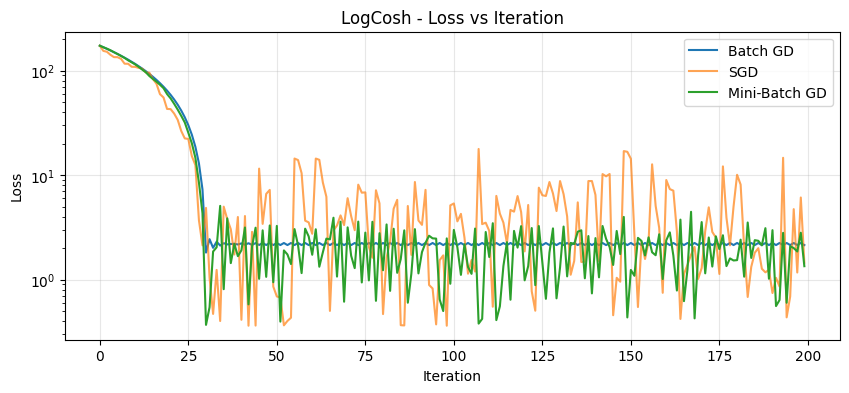

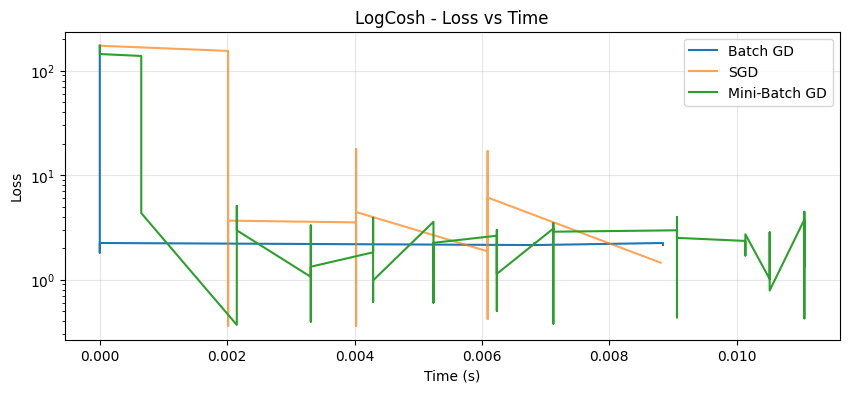

In [82]:
plt.figure(figsize=(10, 4))
plt.plot(h_bgd_lc['loss'], label='Batch GD')
plt.plot(h_sgd_lc['loss'], label='SGD', alpha=0.7)
plt.plot(h_mbgd_lc['loss'], label='Mini-Batch GD')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('LogCosh - Loss vs Iteration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(h_bgd_lc['time'], h_bgd_lc['loss'], label='Batch GD')
plt.plot(h_sgd_lc['time'], h_sgd_lc['loss'], label='SGD', alpha=0.7)
plt.plot(h_mbgd_lc['time'], h_mbgd_lc['loss'], label='Mini-Batch GD')
plt.yscale('log')
plt.xlabel('Time (s)')
plt.ylabel('Loss')
plt.title('LogCosh - Loss vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [83]:
lr_f = 0.0001

w_bgd_f, h_bgd_f = batch_gd(X, y, w_init, binary_focal_grad, binary_focal_grad, lr_f, epochs=200)
w_sgd_f, h_sgd_f = stochastic_gd(X, y, w_init, binary_focal_grad, binary_focal_grad, lr_f, epochs=200)
w_mbgd_f, h_mbgd_f = mini_batch_gd(X, y, w_init, binary_focal_grad, binary_focal_grad, lr_f, epochs=200)

print("BGD:", w_bgd_f, "Loss:", h_bgd_f['loss'][-1])
print("SGD:", w_sgd_f, "Loss:", h_sgd_f['loss'][-1])
print("MBGD:", w_mbgd_f, "Loss:", h_mbgd_f['loss'][-1])

BGD: [-0.89532811  0.51691735] Loss: [ 45.48935632 -26.2632711 ]
SGD: [ 0.58020447 -0.33496556] Loss: [-20.08298761  11.59493518]
MBGD: [-1.0019178   0.57845847] Loss: [ 45.48863227 -26.26285199]


In [84]:
# plt.figure(figsize=(10, 4))
# plt.plot(h_bgd_f['loss'], label='Batch GD')
# # plt.plot(h_sgd_f['loss'], label='SGD', alpha=0.7)
# # plt.plot(h_mbgd_f['loss'], label='Mini-Batch GD')
# plt.xlabel('Iteration')
# plt.ylabel('Loss')
# plt.title('Focal - Loss vs Iteration')
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()

In [85]:
# Real-world Dataset 1: Iris Dataset
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_d = iris.data[:, :2]  # Use first 2 features (sepal length, sepal width)
y_d = iris.target.astype(float)  # Target as float for regression

scaler = StandardScaler()
X_d = scaler.fit_transform(X_d)

print("Iris shape:", X_d.shape, y_d.shape)

Iris shape: (150, 2) (150,)


In [86]:
w_bgd_d, h_bgd_d = batch_gd(X_d, y_d, w_init, mse_loss, mse_grad, 0.0001, epochs=200)
w_sgd_d, h_sgd_d = stochastic_gd(X_d, y_d, w_init, mse_loss, mse_grad, 0.0001, epochs=200)
w_mbgd_d, h_mbgd_d = mini_batch_gd(X_d, y_d, w_init, mse_loss, mse_grad, 0.0001, epochs=200)

print("BGD:", w_bgd_d, "Loss:", h_bgd_d['loss'][-1])
print("SGD:", w_sgd_d, "Loss:", h_sgd_d['loss'][-1])
print("MBGD:", w_mbgd_d, "Loss:", h_mbgd_d['loss'][-1])

BGD: [ 0.02502472 -0.01360271] Loss: 1.6262951509204875
SGD: [ 0.02564689 -0.01138347] Loss: 1.6271730426683317
MBGD: [ 0.02489586 -0.01382513] Loss: 1.6263513342929223


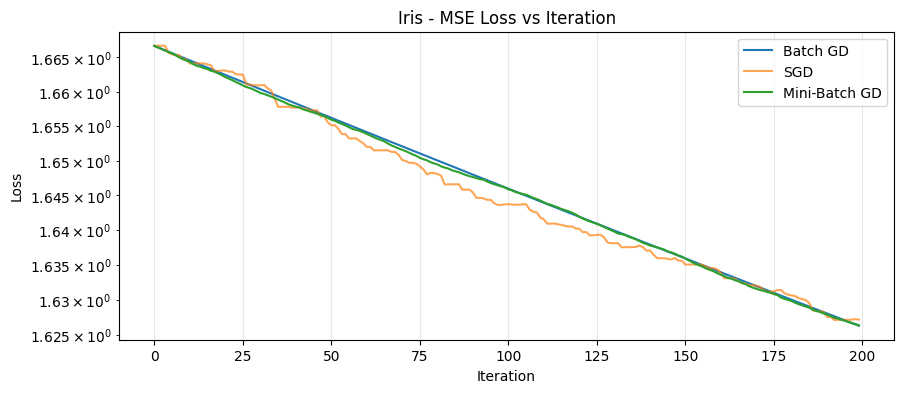

In [87]:
plt.figure(figsize=(10, 4))
plt.plot(h_bgd_d['loss'], label='Batch GD')
plt.plot(h_sgd_d['loss'], label='SGD', alpha=0.7)
plt.plot(h_mbgd_d['loss'], label='Mini-Batch GD')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Iris - MSE Loss vs Iteration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [88]:
# Iris - LogCosh Loss
w_bgd_d_lc, h_bgd_d_lc = batch_gd(X_d, y_d, w_init, logcosh_loss, logcosh_grad, 0.01, epochs=200)
w_sgd_d_lc, h_sgd_d_lc = stochastic_gd(X_d, y_d, w_init, logcosh_loss, logcosh_grad, 0.01, epochs=200)
w_mbgd_d_lc, h_mbgd_d_lc = mini_batch_gd(X_d, y_d, w_init, logcosh_loss, logcosh_grad, 0.01, epochs=200)

print("Iris LogCosh:")
print("BGD:", w_bgd_d_lc, "Loss:", h_bgd_d_lc['loss'][-1])
print("SGD:", w_sgd_d_lc, "Loss:", h_sgd_d_lc['loss'][-1])
print("MBGD:", w_mbgd_d_lc, "Loss:", h_mbgd_d_lc['loss'][-1])

Iris LogCosh:
BGD: [ 0.37296402 -0.2150947 ] Loss: 0.48056978519835764
SGD: [ 0.30041916 -0.3337941 ] Loss: 0.4868167503960194
MBGD: [ 0.38938052 -0.21043723] Loss: 0.4791268756547396


In [89]:
# Iris - Focal Loss
w_bgd_d_f, h_bgd_d_f = batch_gd(X_d, y_d, w_init, binary_focal_loss, binary_focal_grad, 0.001, epochs=200)
w_sgd_d_f, h_sgd_d_f = stochastic_gd(X_d, y_d, w_init, binary_focal_loss, binary_focal_grad, 0.001, epochs=200)
w_mbgd_d_f, h_mbgd_d_f = mini_batch_gd(X_d, y_d, w_init, binary_focal_loss, binary_focal_grad, 0.001, epochs=200)

print("Iris Focal:")
print("BGD:", w_bgd_d_f, "Loss:", h_bgd_d_f['loss'][-1])
print("SGD:", w_sgd_d_f, "Loss:", h_sgd_d_f['loss'][-1])
print("MBGD:", w_mbgd_d_f, "Loss:", h_mbgd_d_f['loss'][-1])

Iris Focal:
BGD: [-0.03979961  0.02183199] Loss: 0.1933512503662594
SGD: [0.00888843 0.00460659] Loss: 0.17107099738052384
MBGD: [-0.04059522  0.02214377] Loss: 0.19374002792104372


In [90]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X_h = housing.data[:1000, :2]
y_h = housing.target[:1000]

scaler_h = StandardScaler()
X_h = scaler_h.fit_transform(X_h)

print("Housing shape:", X_h.shape, y_h.shape)

Housing shape: (1000, 2) (1000,)


In [91]:
w_bgd_h, h_bgd_h = batch_gd(X_h, y_h, w_init, mse_loss, mse_grad, 0.0001, epochs=200)
w_sgd_h, h_sgd_h = stochastic_gd(X_h, y_h, w_init, mse_loss, mse_grad, 0.0001, epochs=200)
w_mbgd_h, h_mbgd_h = mini_batch_gd(X_h, y_h, w_init, mse_loss, mse_grad, 0.0001, epochs=200)

print("BGD:", w_bgd_h, "Loss:", h_bgd_h['loss'][-1])
print("SGD:", w_sgd_h, "Loss:", h_sgd_h['loss'][-1])
print("MBGD:", w_mbgd_h, "Loss:", h_mbgd_h['loss'][-1])

BGD: [ 0.02672772 -0.00468609] Loss: 5.145143421003873
SGD: [ 0.02218861 -0.01536516] Loss: 5.148531837576147
MBGD: [ 0.02704286 -0.00421378] Loss: 5.144951333195801


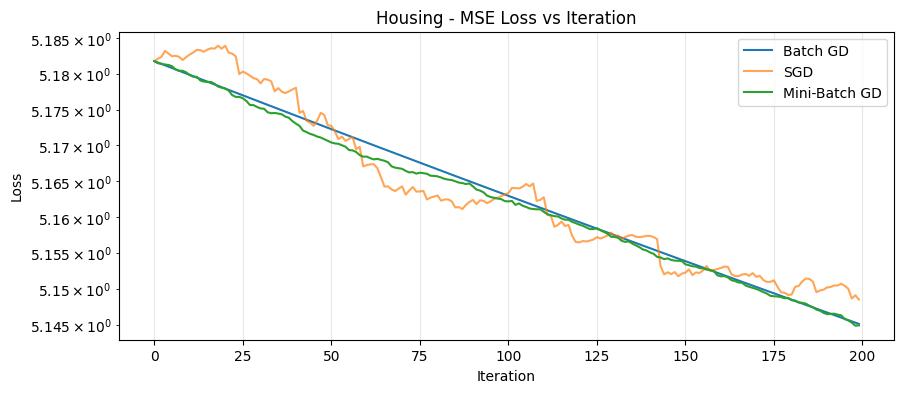

In [92]:
plt.figure(figsize=(10, 4))
plt.plot(h_bgd_h['loss'], label='Batch GD')
plt.plot(h_sgd_h['loss'], label='SGD', alpha=0.7)
plt.plot(h_mbgd_h['loss'], label='Mini-Batch GD')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Housing - MSE Loss vs Iteration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [93]:
# Housing - LogCosh Loss
w_bgd_h_lc, h_bgd_h_lc = batch_gd(X_h, y_h, w_init, logcosh_loss, logcosh_grad, 0.01, epochs=200)
w_sgd_h_lc, h_sgd_h_lc = stochastic_gd(X_h, y_h, w_init, logcosh_loss, logcosh_grad, 0.01, epochs=200)
w_mbgd_h_lc, h_mbgd_h_lc = mini_batch_gd(X_h, y_h, w_init, logcosh_loss, logcosh_grad, 0.01, epochs=200)

print("Housing LogCosh:")
print("BGD:", w_bgd_h_lc, "Loss:", h_bgd_h_lc['loss'][-1])
print("SGD:", w_sgd_h_lc, "Loss:", h_sgd_h_lc['loss'][-1])
print("MBGD:", w_mbgd_h_lc, "Loss:", h_mbgd_h_lc['loss'][-1])

Housing LogCosh:
BGD: [ 0.09372334 -0.03359865] Loss: 1.4372230669176984
SGD: [-0.11827266  0.06562806] Loss: 1.451806633661444
MBGD: [ 0.07952032 -0.03493108] Loss: 1.437739960582487


In [94]:
# Housing - Focal Loss
w_bgd_h_f, h_bgd_h_f = batch_gd(X_h, y_h, w_init, binary_focal_loss, binary_focal_grad, 0.001, epochs=200)
w_sgd_h_f, h_sgd_h_f = stochastic_gd(X_h, y_h, w_init, binary_focal_loss, binary_focal_grad, 0.001, epochs=200)
w_mbgd_h_f, h_mbgd_h_f = mini_batch_gd(X_h, y_h, w_init, binary_focal_loss, binary_focal_grad, 0.001, epochs=200)

print("Housing Focal:")
print("BGD:", w_bgd_h_f, "Loss:", h_bgd_h_f['loss'][-1])
print("SGD:", w_sgd_h_f, "Loss:", h_sgd_h_f['loss'][-1])
print("MBGD:", w_mbgd_h_f, "Loss:", h_mbgd_h_f['loss'][-1])

Housing Focal:
BGD: [-0.01929719  0.0036823 ] Loss: 0.1814560221014397
SGD: [-0.00802401  0.00532452] Loss: 0.1770169676093263
MBGD: [-0.02233395  0.00486053] Loss: 0.18279058474385773


## A. Convergence Log Analysis
Plot Loss vs. Iteration (log scale) and identify:
- Which method is the "smoothest"?
- Which is the most "jittery"?

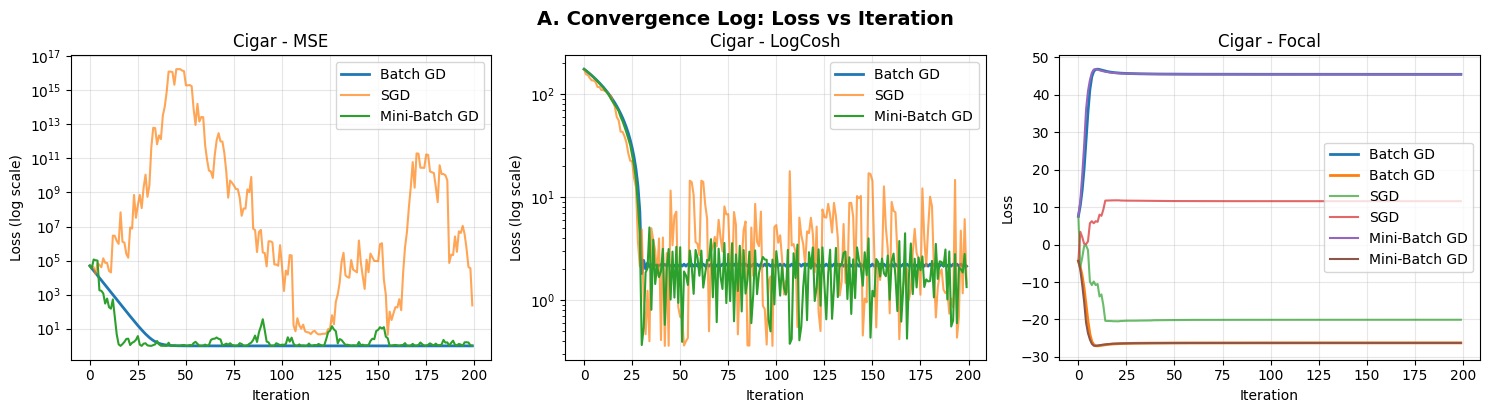

A. CONVERGENCE LOG ANALYSIS

SMOOTHEST method: Batch Gradient Descent (BGD)
   - Uses the entire dataset for each gradient update
   - Gradient direction is consistent, leading to smooth convergence

MOST JITTERY method: Stochastic Gradient Descent (SGD)
   - Uses only one sample per update
   - High variance in gradient estimates causes oscillations

Mini-Batch GD is a compromise between the two:
   - Less jittery than SGD, slightly noisier than BGD


In [95]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(h_bgd['loss'], label='Batch GD', linewidth=2)
axes[0].plot(h_sgd['loss'], label='SGD', alpha=0.7)
axes[0].plot(h_mbgd['loss'], label='Mini-Batch GD')
axes[0].set_yscale('log')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Cigar - MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(h_bgd_lc['loss'], label='Batch GD', linewidth=2)
axes[1].plot(h_sgd_lc['loss'], label='SGD', alpha=0.7)
axes[1].plot(h_mbgd_lc['loss'], label='Mini-Batch GD')
axes[1].set_yscale('log')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Cigar - LogCosh')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(h_bgd_f['loss'], label='Batch GD', linewidth=2)
axes[2].plot(h_sgd_f['loss'], label='SGD', alpha=0.7)
axes[2].plot(h_mbgd_f['loss'], label='Mini-Batch GD')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel('Loss')
axes[2].set_title('Cigar - Focal')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('A. Convergence Log: Loss vs Iteration', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Analysis
print("=" * 70)
print("A. CONVERGENCE LOG ANALYSIS")
print("=" * 70)
print("\nSMOOTHEST method: Batch Gradient Descent (BGD)")
print("   - Uses the entire dataset for each gradient update")
print("   - Gradient direction is consistent, leading to smooth convergence")
print("\nMOST JITTERY method: Stochastic Gradient Descent (SGD)")
print("   - Uses only one sample per update")
print("   - High variance in gradient estimates causes oscillations")
print("\nMini-Batch GD is a compromise between the two:")
print("   - Less jittery than SGD, slightly noisier than BGD")
print("=" * 70)

## B. Weight Trajectory Plot
Create a 2D contour plot of the loss surface with respect to w0 and w1. Overlay the path taken by the weights starting from [0, 0].
- Observe the "zig-zag" behavior
- Which variant struggles most with the elongated "cigar" shape of the loss surface?

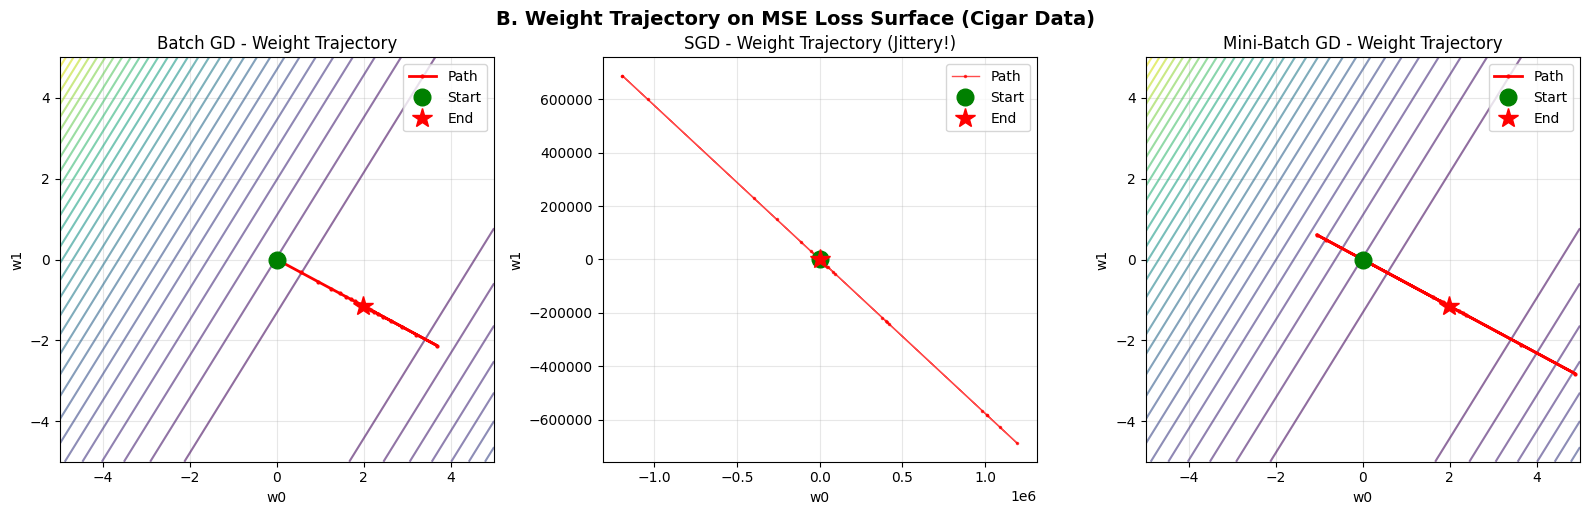

B. WEIGHT TRAJECTORY ANALYSIS

ZIG-ZAG BEHAVIOR:
   - The 'cigar' shaped loss surface has very different curvatures
   - Gradient points towards steepest descent, not towards minimum
   - This causes oscillations perpendicular to the long axis

STRUGGLES MOST: Stochastic Gradient Descent (SGD)
   - Single sample gradients have high variance
   - Path shows extreme zig-zag behavior on the elongated surface
   - May take longer to converge or fail to converge with high LR

HANDLES BEST: Batch GD
   - Consistent gradient direction, smoother trajectory
   - But still shows some zig-zag due to ill-conditioned surface


In [96]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

w0_range = np.linspace(-5, 5, 100)
w1_range = np.linspace(-5, 5, 100)
W0, W1 = np.meshgrid(w0_range, w1_range)
Z = np.zeros_like(W0)
for i in range(len(w0_range)):
    for j in range(len(w1_range)):
        w = np.array([W0[i, j], W1[i, j]])
        Z[i, j] = mse_loss(X, y, w)

axes[0].contour(W0, W1, Z, levels=30, cmap='viridis', alpha=0.6)
weights_bgd = np.array(h_bgd['w'])
axes[0].plot(weights_bgd[:, 0], weights_bgd[:, 1], 'r.-', linewidth=2, markersize=4, label='Path')
axes[0].plot(weights_bgd[0, 0], weights_bgd[0, 1], 'go', markersize=12, label='Start', zorder=5)
axes[0].plot(weights_bgd[-1, 0], weights_bgd[-1, 1], 'r*', markersize=15, label='End', zorder=5)
axes[0].set_xlabel('w0')
axes[0].set_ylabel('w1')
axes[0].set_title('Batch GD - Weight Trajectory')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].contour(W0, W1, Z, levels=30, cmap='viridis', alpha=0.6)
weights_sgd = np.array(h_sgd['w'])
axes[1].plot(weights_sgd[:, 0], weights_sgd[:, 1], 'r.-', linewidth=1, markersize=3, alpha=0.7, label='Path')
axes[1].plot(weights_sgd[0, 0], weights_sgd[0, 1], 'go', markersize=12, label='Start', zorder=5)
axes[1].plot(weights_sgd[-1, 0], weights_sgd[-1, 1], 'r*', markersize=15, label='End', zorder=5)
axes[1].set_xlabel('w0')
axes[1].set_ylabel('w1')
axes[1].set_title('SGD - Weight Trajectory (Jittery!)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].contour(W0, W1, Z, levels=30, cmap='viridis', alpha=0.6)
weights_mbgd = np.array(h_mbgd['w'])
axes[2].plot(weights_mbgd[:, 0], weights_mbgd[:, 1], 'r.-', linewidth=2, markersize=4, label='Path')
axes[2].plot(weights_mbgd[0, 0], weights_mbgd[0, 1], 'go', markersize=12, label='Start', zorder=5)
axes[2].plot(weights_mbgd[-1, 0], weights_mbgd[-1, 1], 'r*', markersize=15, label='End', zorder=5)
axes[2].set_xlabel('w0')
axes[2].set_ylabel('w1')
axes[2].set_title('Mini-Batch GD - Weight Trajectory')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('B. Weight Trajectory on MSE Loss Surface (Cigar Data)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("=" * 70)
print("B. WEIGHT TRAJECTORY ANALYSIS")
print("=" * 70)
print("\nZIG-ZAG BEHAVIOR:")
print("   - The 'cigar' shaped loss surface has very different curvatures")
print("   - Gradient points towards steepest descent, not towards minimum")
print("   - This causes oscillations perpendicular to the long axis")
print("\nSTRUGGLES MOST: Stochastic Gradient Descent (SGD)")
print("   - Single sample gradients have high variance")
print("   - Path shows extreme zig-zag behavior on the elongated surface")
print("   - May take longer to converge or fail to converge with high LR")
print("\nHANDLES BEST: Batch GD")
print("   - Consistent gradient direction, smoother trajectory")
print("   - But still shows some zig-zag due to ill-conditioned surface")
print("=" * 70)

## C. Wall-Clock Efficiency

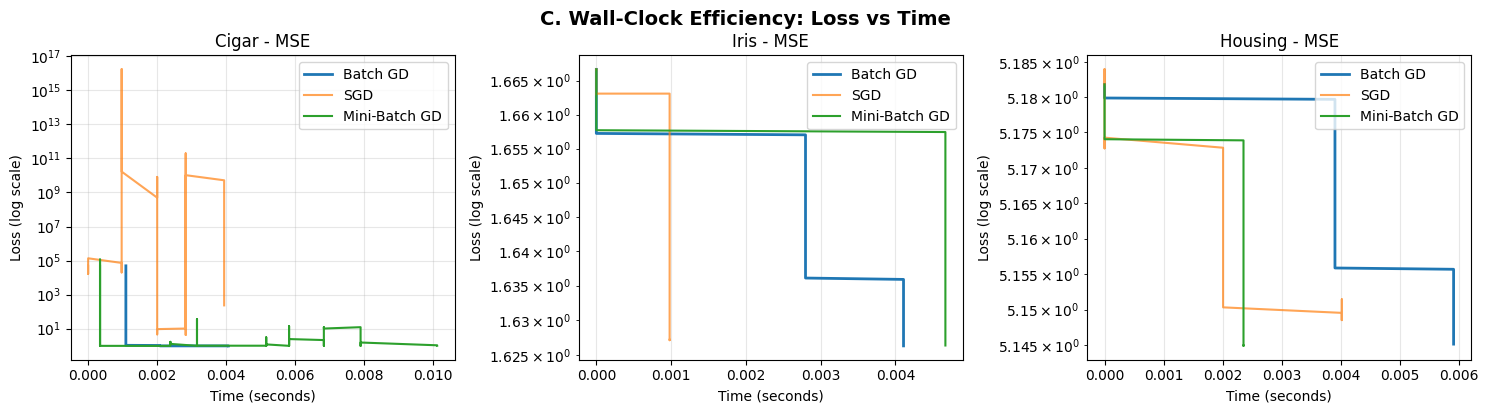

C. WALL-CLOCK EFFICIENCY ANALYSIS

FASTEST to reach good loss: SGD / Mini-Batch GD
   - Each iteration is faster (computes gradient on fewer samples)
   - For large datasets, can make more updates in same time

BGD takes more time per iteration:
   - Must process entire dataset for each update
   - On small datasets (like these), difference is minimal

KEY INSIGHT:
   - For SMALL datasets: All methods similar in wall-clock time
   - For LARGE datasets: SGD/MBGD reach good loss faster
   - But SGD may need more iterations to stabilize


In [97]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(h_bgd['time'], h_bgd['loss'], label='Batch GD', linewidth=2)
axes[0].plot(h_sgd['time'], h_sgd['loss'], label='SGD', alpha=0.7)
axes[0].plot(h_mbgd['time'], h_mbgd['loss'], label='Mini-Batch GD')
axes[0].set_yscale('log')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Cigar - MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(h_bgd_d['time'], h_bgd_d['loss'], label='Batch GD', linewidth=2)
axes[1].plot(h_sgd_d['time'], h_sgd_d['loss'], label='SGD', alpha=0.7)
axes[1].plot(h_mbgd_d['time'], h_mbgd_d['loss'], label='Mini-Batch GD')
axes[1].set_yscale('log')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Loss (log scale)')
axes[1].set_title('Iris - MSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(h_bgd_h['time'], h_bgd_h['loss'], label='Batch GD', linewidth=2)
axes[2].plot(h_sgd_h['time'], h_sgd_h['loss'], label='SGD', alpha=0.7)
axes[2].plot(h_mbgd_h['time'], h_mbgd_h['loss'], label='Mini-Batch GD')
axes[2].set_yscale('log')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Loss (log scale)')
axes[2].set_title('Housing - MSE')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('C. Wall-Clock Efficiency: Loss vs Time', y=1.02, fontsize=14, fontweight='bold')
plt.show()

print("=" * 70)
print("C. WALL-CLOCK EFFICIENCY ANALYSIS")
print("=" * 70)
print("\nFASTEST to reach good loss: SGD / Mini-Batch GD")
print("   - Each iteration is faster (computes gradient on fewer samples)")
print("   - For large datasets, can make more updates in same time")
print("\nBGD takes more time per iteration:")
print("   - Must process entire dataset for each update")
print("   - On small datasets (like these), difference is minimal")
print("\nKEY INSIGHT:")
print("   - For SMALL datasets: All methods similar in wall-clock time")
print("   - For LARGE datasets: SGD/MBGD reach good loss faster")
print("   - But SGD may need more iterations to stabilize")
print("=" * 70)

In [98]:
def _fmt_loss(value):
    value = np.asarray(value)
    if value.size == 1:
        return f"{float(value):.4f}"
    return f"{float(value.ravel()[0]):.4f}"

print("=" * 80)
print("FINAL COMPARISON - ALL DATASETS x ALL LOSS FUNCTIONS x ALL GD VARIANTS")
print("=" * 80)

print("\nCIGAR (Synthetic Data):")
print(f"   MSE      - BGD: {_fmt_loss(h_bgd['loss'][-1])}, SGD: {_fmt_loss(h_sgd['loss'][-1])}, MBGD: {_fmt_loss(h_mbgd['loss'][-1])}")
print(f"   LogCosh  - BGD: {_fmt_loss(h_bgd_lc['loss'][-1])}, SGD: {_fmt_loss(h_sgd_lc['loss'][-1])}, MBGD: {_fmt_loss(h_mbgd_lc['loss'][-1])}")
print(f"   Focal    - BGD: {_fmt_loss(h_bgd_f['loss'][-1])}, SGD: {_fmt_loss(h_sgd_f['loss'][-1])}, MBGD: {_fmt_loss(h_mbgd_f['loss'][-1])}")

print("\nIRIS (Real Dataset 1):")
print(f"   MSE      - BGD: {_fmt_loss(h_bgd_d['loss'][-1])}, SGD: {_fmt_loss(h_sgd_d['loss'][-1])}, MBGD: {_fmt_loss(h_mbgd_d['loss'][-1])}")
print(f"   LogCosh  - BGD: {_fmt_loss(h_bgd_d_lc['loss'][-1])}, SGD: {_fmt_loss(h_sgd_d_lc['loss'][-1])}, MBGD: {_fmt_loss(h_mbgd_d_lc['loss'][-1])}")
print(f"   Focal    - BGD: {_fmt_loss(h_bgd_d_f['loss'][-1])}, SGD: {_fmt_loss(h_sgd_d_f['loss'][-1])}, MBGD: {_fmt_loss(h_mbgd_d_f['loss'][-1])}")

print("\nCALIFORNIA HOUSING (Real Dataset 2):")
print(f"   MSE      - BGD: {_fmt_loss(h_bgd_h['loss'][-1])}, SGD: {_fmt_loss(h_sgd_h['loss'][-1])}, MBGD: {_fmt_loss(h_mbgd_h['loss'][-1])}")
print(f"   LogCosh  - BGD: {_fmt_loss(h_bgd_h_lc['loss'][-1])}, SGD: {_fmt_loss(h_sgd_h_lc['loss'][-1])}, MBGD: {_fmt_loss(h_mbgd_h_lc['loss'][-1])}")
print(f"   Focal    - BGD: {_fmt_loss(h_bgd_h_f['loss'][-1])}, SGD: {_fmt_loss(h_sgd_h_f['loss'][-1])}, MBGD: {_fmt_loss(h_mbgd_h_f['loss'][-1])}")

print("\n" + "=" * 80)

FINAL COMPARISON - ALL DATASETS x ALL LOSS FUNCTIONS x ALL GD VARIANTS

CIGAR (Synthetic Data):
   MSE      - BGD: 0.9653, SGD: 231.7604, MBGD: 0.9900
   LogCosh  - BGD: 2.1445, SGD: 1.4556, MBGD: 1.3462
   Focal    - BGD: 45.4894, SGD: -20.0830, MBGD: 45.4886

IRIS (Real Dataset 1):
   MSE      - BGD: 1.6263, SGD: 1.6272, MBGD: 1.6264
   LogCosh  - BGD: 0.4806, SGD: 0.4868, MBGD: 0.4791
   Focal    - BGD: 0.1934, SGD: 0.1711, MBGD: 0.1937

CALIFORNIA HOUSING (Real Dataset 2):
   MSE      - BGD: 5.1451, SGD: 5.1485, MBGD: 5.1450
   LogCosh  - BGD: 1.4372, SGD: 1.4518, MBGD: 1.4377
   Focal    - BGD: 0.1815, SGD: 0.1770, MBGD: 0.1828

